Supportlytics — IT Support Ticket Analysis
Week 1: Data Acquisition & Understanding 




1.1 Import libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

1.2 Load the dataset

In [27]:
df = pd.read_csv('helpdesk_tickets.csv')
print("Shape:", df.shape)
df.head()

Shape: (1000000, 11)


,Ticket_ID,Date_Created,Date_Resolved,Category,Subcategory,Priority,Status,Assigned_Team,Resolution_Time_Hrs,Description,Escalated
0,1,2023-11-16,2023-11-23,Access,Access denied by auditor policy,Low,Open,Desktop Support,3.56,User reported Access denied by auditor policy....,True
1,2,2023-11-29,2023-12-02,Security,Suspicious DLL injection,Critical,Open,Security Team,4.14,User reported Suspicious DLL injection. Furthe...,False
2,3,2023-11-29,2023-12-06,Security,Suspicious SOC alert,Low,Pending,Security Team,2.98,User reported Suspicious SOC alert. Further in...,True
3,4,2023-11-04,2023-11-09,Software,App freezing,Low,On Hold,Application Support,4.45,User reported App freezing. Further investigat...,False
4,5,2023-11-03,2023-11-10,Access,Access logging failure,Critical,In Progress,Desktop Support,3.49,User reported Access logging failure. Further ...,True


1.3 Inspect structure, column types, and relationships

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   Ticket_ID            1000000 non-null  int64  
 1   Date_Created         1000000 non-null  str    
 2   Date_Resolved        700057 non-null   str    
 3   Category             1000000 non-null  str    
 4   Subcategory          1000000 non-null  str    
 5   Priority             1000000 non-null  str    
 6   Status               1000000 non-null  str    
 7   Assigned_Team        1000000 non-null  str    
 8   Resolution_Time_Hrs  1000000 non-null  float64
 9   Description          1000000 non-null  str    
 10  Escalated            1000000 non-null  bool   
dtypes: bool(1), float64(1), int64(1), str(8)
memory usage: 77.2 MB


In [29]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Ticket_ID,1000000.0,NaN,NaN,NaN,500000.5,288675.278932,1.0,250000.75,500000.5,750000.25,1000000.0
Date_Created,1000000,30,2023-11-03,33717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date_Resolved,700057,36,2023-11-21,23507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,1000000,5,Software,200628,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Subcategory,1000000,493,Laptop touch screen not working,2166,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Priority,1000000,4,Low,250419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,1000000,5,Resolved,200903,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Assigned_Team,1000000,4,Desktop Support,399425,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Resolution_Time_Hrs,1000000.0,NaN,NaN,NaN,5.246152,2.742932,0.5,2.87,5.24,7.62,10.0
Description,1000000,493,User reported Laptop touch screen not working....,2166,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# Unique value counts for categorical columns
cat_cols = ['Category', 'Subcategory', 'Priority', 'Status', 'Assigned_Team', 'Escalated']
for col in cat_cols:
    print(f"--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts())
    print()

--- Category (5 unique) ---
Category
Software    200628
Security    200004
Network     199943
Hardware    199761
Access      199664
Name: count, dtype: int64

--- Subcategory (493 unique) ---
Subcategory
Laptop touch screen not working           2166
Laptop motherboard short circuit          2161
Keyboard malfunction                      2149
DHCP failure                              2146
Suspicious cookie theft                   2141
                                          ... 
Access denied by SOX policy               1900
Access denied by HIPAA policy             1899
Access denied by auditor policy           1893
Access denied by temporary restriction    1892
Account disabled by policy                1887
Name: count, Length: 493, dtype: int64

--- Priority (4 unique) ---
Priority
Low         250419
Medium      250158
High        249853
Critical    249570
Name: count, dtype: int64

--- Status (5 unique) ---
Status
Resolved       200903
On Hold        200519
Open           199802


1.4 Missing values check

In [31]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
Ticket_ID,0,0.00
Date_Created,0,0.00
Date_Resolved,299943,29.99
Category,0,0.00
Subcategory,0,0.00
Priority,0,0.00
Status,0,0.00
Assigned_Team,0,0.00
Resolution_Time_Hrs,0,0.00
Description,0,0.00


1.5 Duplicate check

In [32]:
print("Duplicate Ticket_IDs:", df['Ticket_ID'].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())

Duplicate Ticket_IDs: 0
Fully duplicate rows: 0


1.6 Define key metrics

In [33]:
df['Date_Created'] = pd.to_datetime(df['Date_Created'])
df['Date_Resolved'] = pd.to_datetime(df['Date_Resolved'])

priority_dist = df['Priority'].value_counts(normalize=True).mul(100).round(2)
print("Priority distribution (%):")
print(priority_dist)

Priority distribution (%):
Priority
Low         25.04
Medium      25.02
High        24.99
Critical    24.96
Name: proportion, dtype: float64


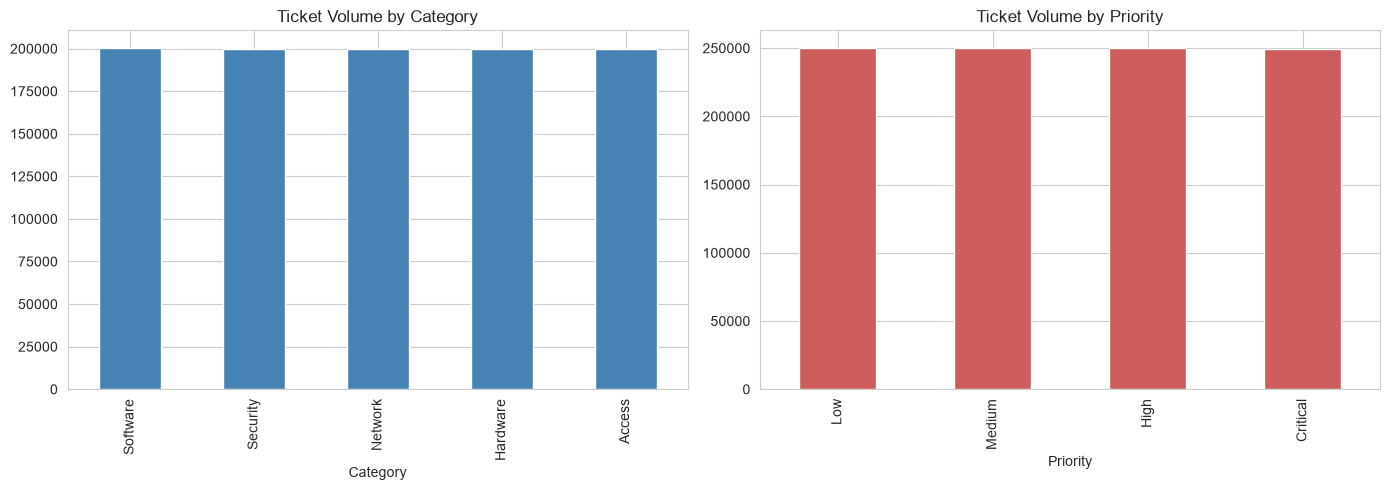

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['Category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', title='Ticket Volume by Category')
df['Priority'].value_counts().plot(kind='bar', ax=axes[1], color='indianred', title='Ticket Volume by Priority')
plt.tight_layout()
plt.show()

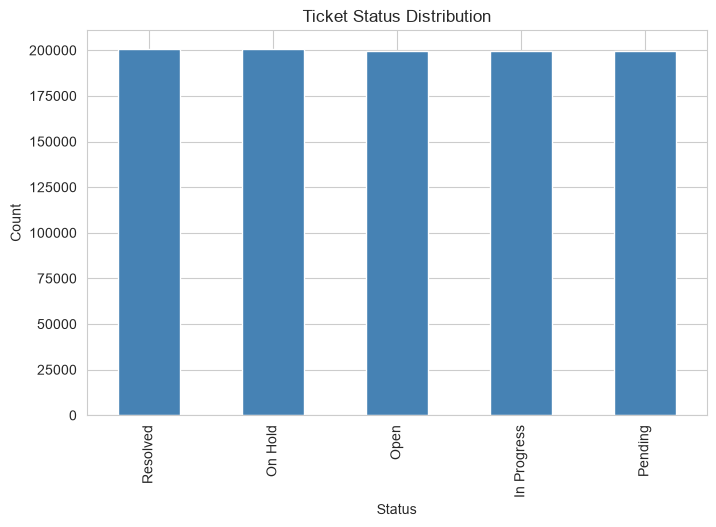

In [35]:
plt.figure(figsize=(8,5))
df['Status'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Ticket Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

Week 2 — Data Cleaning and Feature Engineering

2.1 Handle missing / incomplete fields


In [36]:
df['Is_Resolved'] = df['Date_Resolved'].notnull()
print(df['Is_Resolved'].value_counts())

# Cross-check against Status field
pd.crosstab(df['Status'], df['Is_Resolved'])

Is_Resolved
True     700057
False    299943
Name: count, dtype: int64


Is_Resolved,False,True
Status,,
In Progress,59593,139842
On Hold,59951,140568
Open,60044,139758
Pending,60031,139310
Resolved,60324,140579


2.2 Extract Resolution_Time


In [37]:
df['Resolution_Time_Days'] = (df['Date_Resolved'] - df['Date_Created']).dt.days
df['Resolution_Time_Computed_Hrs'] = df['Resolution_Time_Days'] * 24

df[['Ticket_ID', 'Date_Created', 'Date_Resolved',
    'Resolution_Time_Hrs', 'Resolution_Time_Computed_Hrs']].head(10)

,Ticket_ID,Date_Created,Date_Resolved,Resolution_Time_Hrs,Resolution_Time_Computed_Hrs
0,1,2023-11-16,2023-11-23,3.56,168.0
1,2,2023-11-29,2023-12-02,4.14,72.0
2,3,2023-11-29,2023-12-06,2.98,168.0
3,4,2023-11-04,2023-11-09,4.45,120.0
4,5,2023-11-03,2023-11-10,3.49,168.0
5,6,2023-11-04,NaT,5.29,NaN
6,7,2023-11-20,2023-11-25,8.98,120.0
7,8,2023-11-17,2023-11-20,7.78,72.0
8,9,2023-11-28,2023-12-05,6.57,168.0
9,10,2023-11-30,2023-12-05,8.77,120.0


In [38]:
# Sanity check: distribution of the recomputed metric for resolved tickets
resolved = df[df['Is_Resolved']]
resolved['Resolution_Time_Computed_Hrs'].describe()

count    700057.000000
mean         95.965786
std          48.003193
min          24.000000
25%          48.000000
50%          96.000000
75%         144.000000
max         168.000000
Name: Resolution_Time_Computed_Hrs, dtype: float64

2.3 Categorize performance buckets

In [39]:
def bucket_resolution(hours):
    if pd.isna(hours):
        return 'Unresolved'
    elif hours <= 48:
        return 'Fast'
    elif hours <= 120:
        return 'Moderate'
    else:
        return 'Slow'

df['Performance_Bucket'] = df['Resolution_Time_Computed_Hrs'].apply(bucket_resolution)
df['Performance_Bucket'].value_counts()

Performance_Bucket
Moderate      300377
Unresolved    299943
Fast          200230
Slow          199450
Name: count, dtype: int64

2.4 Encode categorical fields

In [40]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [41]:
from sklearn.preprocessing import LabelEncoder

# Ordinal encode Priority (has a natural order)
priority_order = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
df['Priority_Encoded'] = df['Priority'].map(priority_order)

# One-hot encode nominal fields for downstream modeling/clustering
df_encoded = pd.get_dummies(
    df,
    columns=['Category', 'Status', 'Assigned_Team', 'Performance_Bucket'],
    prefix=['Cat', 'Status', 'Team', 'Perf']
)

# Label encode Subcategory (high cardinality -> keep as single numeric column)
le = LabelEncoder()
df['Subcategory_Encoded'] = le.fit_transform(df['Subcategory'])

df_encoded.head()

,Ticket_ID,Date_Created,Date_Resolved,Subcategory,Priority,Resolution_Time_Hrs,Description,Escalated,Is_Resolved,Resolution_Time_Days,Resolution_Time_Computed_Hrs,Priority_Encoded,Cat_Access,Cat_Hardware,Cat_Network,Cat_Security,Cat_Software,Status_In Progress,Status_On Hold,Status_Open,Status_Pending,Status_Resolved,Team_Application Support,Team_Desktop Support,Team_Network Team,Team_Security Team,Perf_Fast,Perf_Moderate,Perf_Slow,Perf_Unresolved
0,1,2023-11-16,2023-11-23,Access denied by auditor policy,Low,3.56,User reported Access denied by auditor policy....,True,True,7.0,168.0,0,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False
1,2,2023-11-29,2023-12-02,Suspicious DLL injection,Critical,4.14,User reported Suspicious DLL injection. Furthe...,False,True,3.0,72.0,3,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,True,False,False
2,3,2023-11-29,2023-12-06,Suspicious SOC alert,Low,2.98,User reported Suspicious SOC alert. Further in...,True,True,7.0,168.0,0,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,True,False
3,4,2023-11-04,2023-11-09,App freezing,Low,4.45,User reported App freezing. Further investigat...,False,True,5.0,120.0,0,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,True,False,False
4,5,2023-11-03,2023-11-10,Access logging failure,Critical,3.49,User reported Access logging failure. Further ...,True,True,7.0,168.0,3,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False


In [42]:
from sklearn.preprocessing import LabelEncoder

# Ordinal encode Priority (has a natural order)
priority_order = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
df['Priority_Encoded'] = df['Priority'].map(priority_order)

# One-hot encode nominal fields for downstream modeling/clustering
df_encoded = pd.get_dummies(
    df,
    columns=['Category', 'Status', 'Assigned_Team', 'Performance_Bucket'],
    prefix=['Cat', 'Status', 'Team', 'Perf']
)

# Label encode Subcategory (high cardinality -> keep as single numeric column)
le = LabelEncoder()
df['Subcategory_Encoded'] = le.fit_transform(df['Subcategory'])

df_encoded.head()

,Ticket_ID,Date_Created,Date_Resolved,Subcategory,Priority,Resolution_Time_Hrs,Description,Escalated,Is_Resolved,Resolution_Time_Days,Resolution_Time_Computed_Hrs,Priority_Encoded,Subcategory_Encoded,Cat_Access,Cat_Hardware,Cat_Network,Cat_Security,Cat_Software,Status_In Progress,Status_On Hold,Status_Open,Status_Pending,Status_Resolved,Team_Application Support,Team_Desktop Support,Team_Network Team,Team_Security Team,Perf_Fast,Perf_Moderate,Perf_Slow,Perf_Unresolved
0,1,2023-11-16,2023-11-23,Access denied by auditor policy,Low,3.56,User reported Access denied by auditor policy....,True,True,7.0,168.0,0,29,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False
1,2,2023-11-29,2023-12-02,Suspicious DLL injection,Critical,4.14,User reported Suspicious DLL injection. Furthe...,False,True,3.0,72.0,3,396,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,True,False,False
2,3,2023-11-29,2023-12-06,Suspicious SOC alert,Low,2.98,User reported Suspicious SOC alert. Further in...,True,True,7.0,168.0,0,415,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,True,False
3,4,2023-11-04,2023-11-09,App freezing,Low,4.45,User reported App freezing. Further investigat...,False,True,5.0,120.0,0,76,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,True,False,False
4,5,2023-11-03,2023-11-10,Access logging failure,Critical,3.49,User reported Access logging failure. Further ...,True,True,7.0,168.0,3,61,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False


2.5 Save the cleaned dataset

In [43]:
df.to_csv('helpdesk_tickets_cleaned.csv', index=False)
df_encoded.to_csv('helpdesk_tickets_encoded.csv', index=False)
print("Saved cleaned and encoded datasets.")
print("df shape:", df.shape, "| df_encoded shape:", df_encoded.shape)

Saved cleaned and encoded datasets.
df shape: (1000000, 17) | df_encoded shape: (1000000, 31)


Module 3: Exploratory Visualization

### 3.0 Load the cleaned dataset
Continuing from the cleaned output of Module 2.

In [44]:
df = pd.read_csv('helpdesk_tickets_cleaned.csv')
df['Date_Created'] = pd.to_datetime(df['Date_Created'])
df['Date_Resolved'] = pd.to_datetime(df['Date_Resolved'])
print(df.shape)
df.head()

(1000000, 17)


,Ticket_ID,Date_Created,Date_Resolved,Category,Subcategory,Priority,Status,Assigned_Team,Resolution_Time_Hrs,Description,Escalated,Is_Resolved,Resolution_Time_Days,Resolution_Time_Computed_Hrs,Performance_Bucket,Priority_Encoded,Subcategory_Encoded
0,1,2023-11-16,2023-11-23,Access,Access denied by auditor policy,Low,Open,Desktop Support,3.56,User reported Access denied by auditor policy....,True,True,7.0,168.0,Slow,0,29
1,2,2023-11-29,2023-12-02,Security,Suspicious DLL injection,Critical,Open,Security Team,4.14,User reported Suspicious DLL injection. Furthe...,False,True,3.0,72.0,Moderate,3,396
2,3,2023-11-29,2023-12-06,Security,Suspicious SOC alert,Low,Pending,Security Team,2.98,User reported Suspicious SOC alert. Further in...,True,True,7.0,168.0,Slow,0,415
3,4,2023-11-04,2023-11-09,Software,App freezing,Low,On Hold,Application Support,4.45,User reported App freezing. Further investigat...,False,True,5.0,120.0,Moderate,0,76
4,5,2023-11-03,2023-11-10,Access,Access logging failure,Critical,In Progress,Desktop Support,3.49,User reported Access logging failure. Further ...,True,True,7.0,168.0,Slow,3,61


### 3.1 Ticket type distribution
This dataset doesn't carry a separate `Ticket_Type` field, so `Category` is the closest equivalent —
it's the top-level classification every ticket is routed under.

Category
Software    200628
Security    200004
Network     199943
Hardware    199761
Access      199664
Name: count, dtype: int64


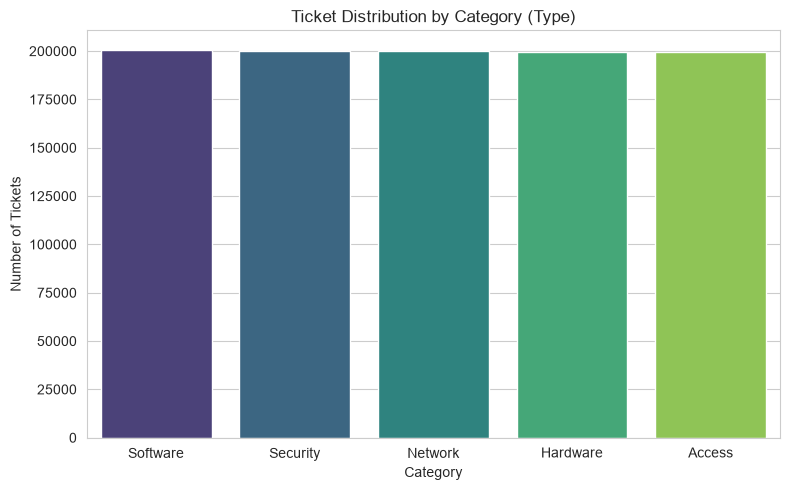

In [45]:
category_counts = df['Category'].value_counts()
print(category_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_counts.index, y=category_counts.values, hue=category_counts.index,
            palette='viridis', legend=False)
plt.title('Ticket Distribution by Category (Type)')
plt.xlabel('Category')
plt.ylabel('Number of Tickets')
plt.tight_layout()
plt.show()

Top Categories:
Category
Software    200628
Security    200004
Network     199943
Hardware    199761
Access      199664
Name: count, dtype: int64


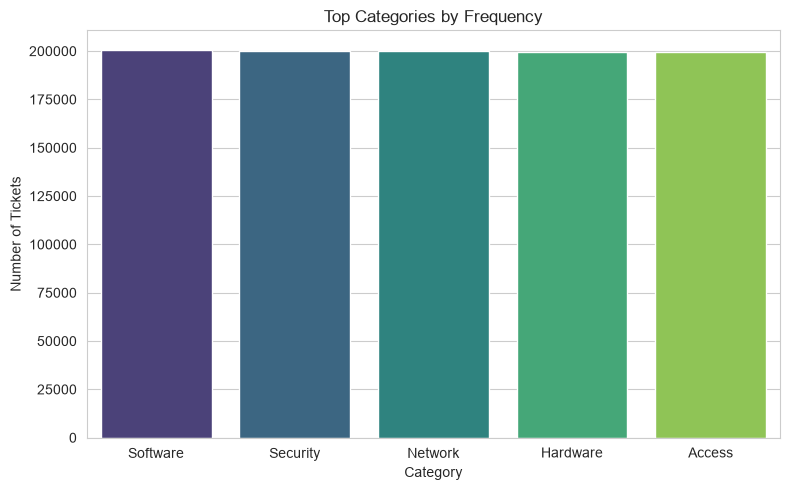

In [46]:
# --- Categories: top-level classification 
top_categories = df['Category'].value_counts()
print("Top Categories:")
print(top_categories)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_categories.index, y=top_categories.values, hue=top_categories.index,
            palette='viridis', legend=False)
plt.title('Top Categories by Frequency')
plt.xlabel('Category')
plt.ylabel('Number of Tickets')
plt.tight_layout()
plt.show()

### 3.2 Top categories and clusters by frequency
True Cluster_ID / Similarity_Score fields come from the text-clustering module (later milestone) —
they don't exist yet in this dataset. As an interim view of "clusters," we use `Subcategory`,
which is the most granular grouping already available, and surface the most frequent ones.

Top Categories:
Category
Software    200628
Security    200004
Network     199943
Hardware    199761
Access      199664
Name: count, dtype: int64

Top 15 Subcategories (proxy for frequent issue clusters):
Subcategory
Laptop touch screen not working     2166
Laptop motherboard short circuit    2161
Keyboard malfunction                2149
DHCP failure                        2146
Suspicious cookie theft             2141
Laptop won’t power on               2140
Laptop screen ghost image           2139
Laptop screen black screen          2136
Laptop screen blue tint             2134
Access denied by server             2131
Duplicate IP detected               2129
Database connection error           2127
External HDD not mounting           2127
Suspicious contractor compromise    2127
Proxy server misconfiguration       2122
Name: count, dtype: int64


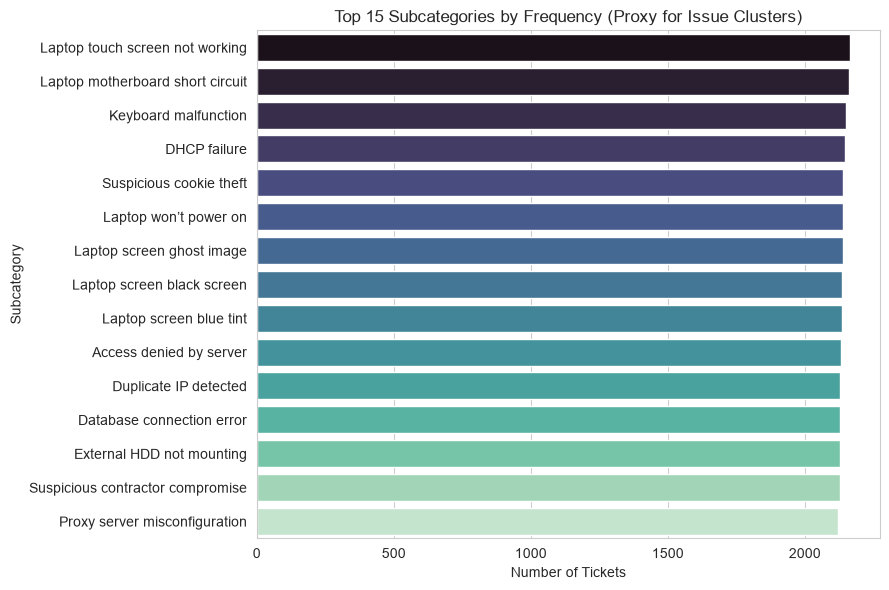

In [47]:
top_categories = df['Category'].value_counts().head(5)
top_subcategories = df['Subcategory'].value_counts().head(15)

print("Top Categories:")
print(top_categories)
print()
print("Top 15 Subcategories (proxy for frequent issue clusters):")
print(top_subcategories)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_subcategories.values, y=top_subcategories.index, hue=top_subcategories.index,
            palette='mako', legend=False)
plt.title('Top 15 Subcategories by Frequency (Proxy for Issue Clusters)')
plt.xlabel('Number of Tickets')
plt.ylabel('Subcategory')
plt.tight_layout()
plt.show()

### 3.3 Tickets by priority

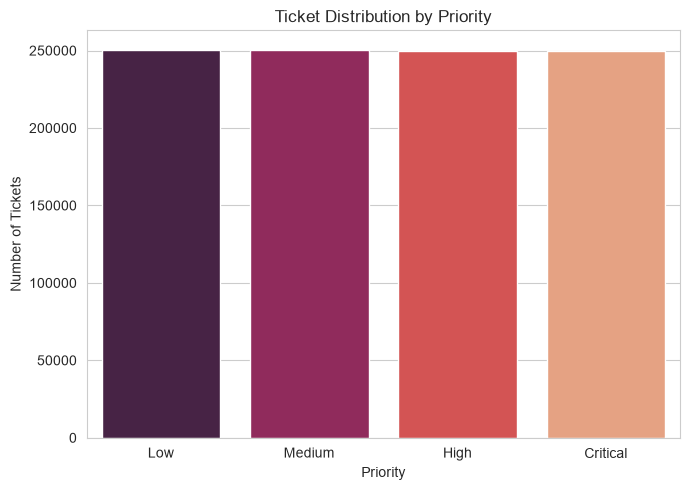

In [48]:
priority_order = ['Low', 'Medium', 'High', 'Critical']
priority_counts = df['Priority'].value_counts().reindex(priority_order)

plt.figure(figsize=(7, 5))
sns.barplot(x=priority_counts.index, y=priority_counts.values, hue=priority_counts.index,
            order=priority_order, palette='rocket', legend=False)
plt.title('Ticket Distribution by Priority')
plt.xlabel('Priority')
plt.ylabel('Number of Tickets')
plt.tight_layout()
plt.show()

### 3.4 Tickets by queue (Assigned_Team)
`Assigned_Team` is the operational "queue" each ticket sits in before being worked.

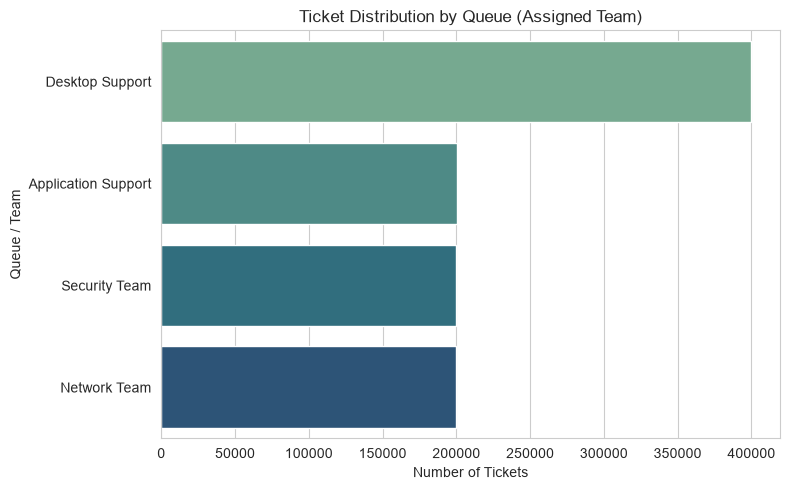

In [49]:
queue_counts = df['Assigned_Team'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=queue_counts.values, y=queue_counts.index, hue=queue_counts.index,
            palette='crest', legend=False)
plt.title('Ticket Distribution by Queue (Assigned Team)')
plt.xlabel('Number of Tickets')
plt.ylabel('Queue / Team')
plt.tight_layout()
plt.show()

### 3.5 Priority x Queue — combined view

Priority               Low  Medium   High  Critical
Assigned_Team                                      
Application Support  50563   50145  50071     49849
Desktop Support      99972  100023  99823     99607
Network Team         49879   49967  49915     50182
Security Team        50005   50023  50044     49932


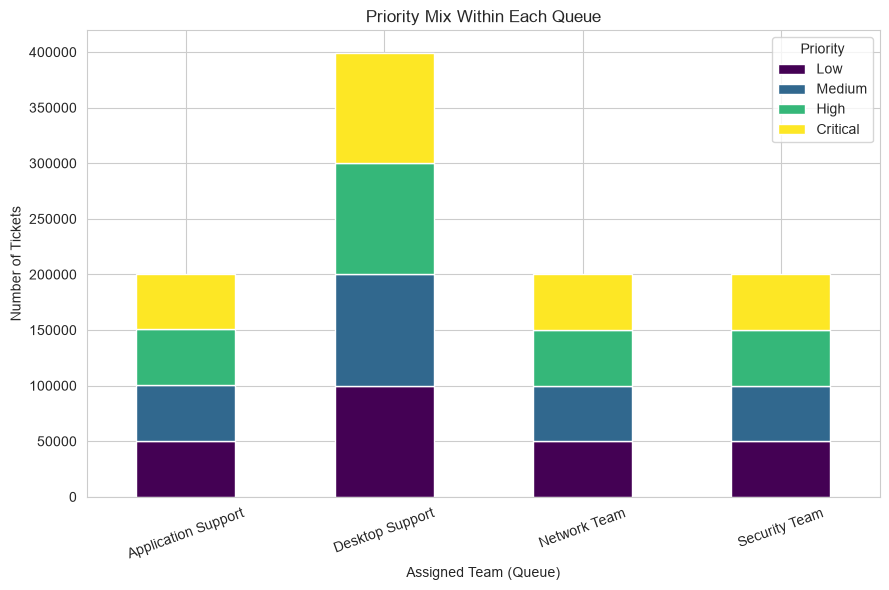

In [50]:
priority_queue = pd.crosstab(df['Assigned_Team'], df['Priority'])[priority_order]
print(priority_queue)

priority_queue.plot(kind='bar', stacked=True, figsize=(9, 6), colormap='viridis')
plt.title('Priority Mix Within Each Queue')
plt.xlabel('Assigned Team (Queue)')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=20)
plt.legend(title='Priority')
plt.tight_layout()
plt.show()

In [51]:
4.1 ##Average similarity scores within clusters

4.1

In [52]:
cluster_summary = df.groupby(['Cluster_ID', 'Cluster_Name']).agg(
    Ticket_Count=('Ticket_ID', 'count'),
    Avg_Similarity=('Similarity_Score', 'mean'),
    Avg_Resolution_Hrs=('Resolution_Time_Computed_Hrs', 'mean')
).reset_index().sort_values('Ticket_Count', ascending=False)

cluster_summary

KeyError: 'Cluster_ID'

In [ ]:
# Viz 1: Average similarity score per cluster
plt.figure(figsize=(10, 6))
sns.barplot(data=cluster_summary.sort_values('Avg_Similarity', ascending=False),
            x='Avg_Similarity', y='Cluster_Name', hue='Cluster_Name', palette='viridis', legend=False)
plt.title('Average Similarity Score by Cluster')
plt.xlabel('Average Similarity Score')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [ ]:
# Viz 2: Cluster size (ticket count)
plt.figure(figsize=(10, 6))
sns.barplot(data=cluster_summary.sort_values('Ticket_Count', ascending=False),
            x='Ticket_Count', y='Cluster_Name', hue='Cluster_Name', palette='mako', legend=False)
plt.title('Cluster Size (Number of Tickets)')
plt.xlabel('Number of Tickets')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [ ]:
4.2 Cluster size vs. issue type (Category)

In [ ]:
# Viz 3: Cluster x Category heatmap
cluster_category = pd.crosstab(df['Cluster_Name'], df['Category'])

plt.figure(figsize=(9, 8))
sns.heatmap(cluster_category, cmap='YlGnBu', annot=False, linewidths=0.3)
plt.title('Cluster vs. Category — Ticket Counts')
plt.xlabel('Category')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [ ]:
# Viz 4: Stacked bar - category composition within each cluster
cluster_category_pct = cluster_category.div(cluster_category.sum(axis=1), axis=0)
cluster_category_pct.plot(kind='barh', stacked=True, figsize=(10, 8), colormap='tab10')
plt.title('Category Composition Within Each Cluster')
plt.xlabel('Share of Tickets')
plt.ylabel('Cluster')
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
4.3 Visualizing performance gaps — boxplots

In [ ]:
# Viz 5: Resolution time distribution by cluster
plt.figure(figsize=(11, 6))
order = cluster_summary.sort_values('Avg_Resolution_Hrs')['Cluster_Name']
sns.boxplot(data=df, x='Cluster_Name', y='Resolution_Time_Computed_Hrs', order=order, hue='Cluster_Name',
            palette='coolwarm', legend=False)
plt.title('Resolution Time Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Resolution Time (Hours)')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Viz 6: Similarity score distribution by Category
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x='Category', y='Similarity_Score', hue='Category', palette='Set2', legend=False)
plt.title('Similarity Score Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Similarity Score')
plt.tight_layout()
plt.show()

In [ ]:
4.4 Visualizing performance gaps — scatter plots

In [ ]:
# Viz 7: Cluster size vs average similarity score
plt.figure(figsize=(8, 6))
sns.scatterplot(data=cluster_summary, x='Ticket_Count', y='Avg_Similarity',
                size='Avg_Resolution_Hrs', hue='Avg_Resolution_Hrs', palette='flare', sizes=(50, 300), legend='brief')
for _, row in cluster_summary.iterrows():
    plt.text(row['Ticket_Count'], row['Avg_Similarity'], row['Cluster_Name'][:14], fontsize=8)
plt.title('Cluster Size vs. Average Similarity (bubble = avg resolution time)')
plt.xlabel('Ticket Count (Cluster Size)')
plt.ylabel('Average Similarity Score')
plt.tight_layout()
plt.show()

In [ ]:
# Viz 8: Cluster size vs average resolution time (identifies problem clusters: large + slow)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=cluster_summary, x='Ticket_Count', y='Avg_Resolution_Hrs',
                hue='Avg_Similarity', palette='viridis', s=120)
for _, row in cluster_summary.iterrows():
    plt.text(row['Ticket_Count'], row['Avg_Resolution_Hrs'], row['Cluster_Name'][:14], fontsize=8)
plt.axhline(cluster_summary['Avg_Resolution_Hrs'].mean(), color='red', linestyle='--', alpha=0.5, label='Overall avg')
plt.title('Cluster Size vs. Average Resolution Time (Problem-Cluster Finder)')
plt.xlabel('Ticket Count (Cluster Size)')
plt.ylabel('Average Resolution Time (Hours)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
Module 5: Performance Trend Analysis


In [ ]:
priority_order = ['Low', 'Medium', 'High', 'Critical']
res_by_priority = df.groupby('Priority')['Resolution_Time_Computed_Hrs'].mean().reindex(priority_order)
res_by_category = df.groupby('Category')['Resolution_Time_Computed_Hrs'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=res_by_priority.index, y=res_by_priority.values, order=priority_order,
            hue=res_by_priority.index, palette='rocket', legend=False, ax=axes[0])
axes[0].set_title('Avg Resolution Time by Priority')
axes[0].set_ylabel('Hours')

sns.barplot(x=res_by_category.index, y=res_by_category.values, hue=res_by_category.index,
            palette='crest', legend=False, ax=axes[1])
axes[1].set_title('Avg Resolution Time by Category (Type)')
axes[1].set_ylabel('Hours')
plt.tight_layout()
plt.show()

In [ ]:
5.2 Which team handles tickets fastest

In [ ]:
team_speed = df.groupby('Assigned_Team')['Resolution_Time_Computed_Hrs'].agg(
    Avg_Resolution_Hrs='mean', Median_Resolution_Hrs='median', Ticket_Count='count'
).sort_values('Avg_Resolution_Hrs')

print(team_speed)

plt.figure(figsize=(8, 5))
sns.barplot(x=team_speed['Avg_Resolution_Hrs'], y=team_speed.index, hue=team_speed.index,
            palette='crest', legend=False)
plt.title('Average Resolution Time by Team (Fastest to Slowest)')
plt.xlabel('Average Resolution Time (Hours)')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

In [ ]:
5.3 High-priority unresolved issues

In [ ]:
high_priority_open = df[(df['Priority'].isin(['High', 'Critical'])) & (~df['Is_Resolved'])]
print(f"High/Critical priority tickets still unresolved: {len(high_priority_open):,} "
      f"({len(high_priority_open) / len(df) * 100:.1f}% of all tickets)")

open_by_team_priority = pd.crosstab(high_priority_open['Assigned_Team'], high_priority_open['Priority'])
print()
print(open_by_team_priority)

open_by_team_priority.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='autumn')
plt.title('Unresolved High/Critical Tickets by Team')
plt.xlabel('Team')
plt.ylabel('Number of Unresolved Tickets')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()